# Lesion Analysis

In [1]:
import os
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn.image import resample_to_img
from nilearn.plotting import plot_stat_map


Cerca tutte le lesion mask MNI per i 4 dataset in `data/clinical_connectome` e verifica che ogni cartella soggetto ne contenga esattamente una.


In [8]:
DATA_ROOT = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/clinical_connectome/derivatives")
DATASETS = ["UNIPD/WashU", "UNIPD/PASPORT", "UNIPD/PSP", "UKLFR/stroke_UKLFR"]
LESION_GLOB = "manual_masks/sub-*/anat/*_label-lesion_mask.nii.gz"

CACHE_DIR = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/derived/lesion_matrix")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

## Lesions Loading

Cerca tutte le lesion mask MNI per i 4 dataset in data/clinical_connectome, verificando che ogni cartella soggetto ne contenga esattamente una (nessun soggetto mancante o duplicato) e che i file trovati siano tutti .nii.gz. Stampa il conteggio per dataset e il totale.

In [9]:
lesion_files: dict[str, list[Path]] = {}

for dataset in DATASETS:
    # Trova le maschere usando il nuovo pattern BIDS
    files = sorted((DATA_ROOT / dataset).glob(LESION_GLOB))

    # Conta le cartelle dei soggetti sotto "manual_masks"
    manual_masks_dir = DATA_ROOT / dataset / "manual_masks"
    if not manual_masks_dir.exists():
        raise ValueError(f"Directory non trovata: {manual_masks_dir}")
        
    n_subject_dirs = len([p for p in manual_masks_dir.iterdir() if p.is_dir()])

    # Validazione ferrea (niente fallback silenziosi)
    if len(files) != n_subject_dirs:
        raise ValueError(
            f"{dataset}: {n_subject_dirs} subject dirs but only "
            f"{len(files)} lesion masks found — check the retrieval report"
        )

    lesion_files[dataset] = files
    print(f"{dataset:25s} {len(files):4d} lesions")

total = sum(len(files) for files in lesion_files.values())
print(f"{'TOTAL':25s} {total:4d} lesions")


UNIPD/WashU                202 lesions
UNIPD/PASPORT               83 lesions
UNIPD/PSP                  168 lesions
UKLFR/stroke_UKLFR         697 lesions
TOTAL                     1150 lesions


## Allineamento e Costruzione della Matrice 

Carica una lesione di riferimento (WashU) per fissare la griglia voxel comune:
- **91×109×91**: numero di voxel lungo i tre assi (x, y, z) della griglia, cioè la shape dell'array 3D.

- **@ 2mm**: dimensione di ciascun voxel lungo ogni asse.
- **MNI152NLin6Asym**: spazio standard in cui sono registrate.
Carica poi ogni lesion mask, la ricampiona sulla griglia comune quando la risoluzione nativa è diversa, la ribinarizza e la appiattisce in un vettore. Infine, impila tutti i vettori in una matrice `X` (soggetti × voxel) e costruisce i `metadata`.


In [5]:
reference_img = nib.load(lesion_files["UNIPD/WashU"][0])
print("reference grid:", reference_img.shape, reference_img.header.get_zooms())

reference grid: (91, 109, 91) (np.float32(2.0), np.float32(2.0), np.float32(2.0))


Carica ogni lesion mask, la ricampiona sulla griglia comune (91×109×91 @ 2mm) quando la risoluzione nativa è diversa, la ribinarizza e la appiattisce in un vettore. 

Impila tutti i vettori in una matrice X (n_soggetti × n_voxel) e costruisce metadata con soggetto e dataset di origine, mantenendo lo stesso ordine di riga per riga tra X e metadata.

In [ ]:
subject_ids: list[str] = []
dataset_labels: list[str] = []
vectors: list[np.ndarray] = []

for dataset, files in lesion_files.items():
    for f in files:
        img = nib.load(f)
        # resample onto the common grid when resolution differs;
        # nearest-neighbor keeps the mask binary
        if img.shape != reference_img.shape:
            img = resample_to_img(
                img, reference_img, interpolation="nearest", force_resample=True, copy_header=True
            )
        # re-binarize: interpolation/registration can leave near-1/near-0 values
        data = img.get_fdata() > 0.5
        # flatten to a 1D vector and convert to uint8 for memory efficiency
        vectors.append(data.ravel().astype(np.uint8))
        subject_ids.append(f.name.split("_")[0])
        dataset_labels.append(dataset)

# stack the list of 1D vectors into a 2D matrix: shape (n_subjects, n_voxels)
X = np.stack(vectors)
# metadataframe has the same order as the rows of X
metadata = pd.DataFrame({"subject_id": subject_ids, "dataset": dataset_labels})
print("X shape:", X.shape)
metadata["dataset"].value_counts()

### Fast loading

Noi l'abbiamo già eseguito, quindi facciamo il loading

In [20]:
print("Caricamento rapido dalla cache in corso...")

# La cartella di produzione già esistente
LOAD_DIR = CACHE_DIR / "21-07_s1.1"

# 1. Carica le matrici pre-calcolate
X_reduced = np.load(LOAD_DIR / "matrix.npy") 
non_constant = np.load(LOAD_DIR / "non_constant_mask.npy")
metadata = pd.read_csv(LOAD_DIR / "metadata.csv")

# 2. Ricostruisci la X gigantesca originale
X = np.zeros((X_reduced.shape[0], len(non_constant)), dtype=np.uint8)
X[:, non_constant] = X_reduced

# 3. Troviamo dinamicamente la primissima maschera usando le TUE variabili
# (serve solo come reference_img per leggere il voxel_volume_mm3 in seguito)
prima_maschera = list((DATA_ROOT / DATASETS[0]).glob(LESION_GLOB))[0]
reference_img = nib.load(prima_maschera)

print(f"X ricostruita fedelmente alla shape originale: {X.shape}")
print(f"Maschera 1D (intero spazio 3D non ridotto). Shape: {non_constant.shape}")
print(f"Metadata caricati con successo. Shape: {metadata.shape}")


Caricamento rapido dalla cache in corso...
X ricostruita fedelmente alla shape originale: (1150, 902629)
Maschera 1D (intero spazio 3D non ridotto). Shape: (902629,)
Metadata caricati con successo. Shape: (1150, 2)


### Sanity Check

In [23]:
# 1. Controlli di base sui valori
unique_values = np.unique(X)
print(f"Valori unici nella matrice 2D ricostruita: {unique_values} (atteso: array([0, 1]))")

# Controllo NaN (se il dtype è intero, i NaN sono strutturalmente impossibili)
if X.dtype.kind == "f":
    print(f"NaN nella matrice: {int(np.isnan(X).sum())}")
else:
    print(f"Matrice dtype={X.dtype} (intero) -> NaN strutturalmente impossibile, controllo superato.")

# 2. Controllo dei pazienti a cui è "sparita" la lesione 
# (Cerchiamo pazienti in cui la somma dei voxel lesionali è esattamente 0)
zero_load_subjects = metadata.loc[X.sum(axis=1) == 0, "subject_id"].tolist()
print(f"\nSoggetti con volume lesionale a zero: {len(zero_load_subjects)}")
if zero_load_subjects:
    print(f"  -> {zero_load_subjects} (Attenzione: potresti volerli rimuovere!)")


Valori unici nella matrice 2D ricostruita: [0 1] (atteso: array([0, 1]))
Matrice dtype=uint8 (intero) -> NaN strutturalmente impossibile, controllo superato.

Soggetti con volume lesionale a zero: 0


## Matrix visualization

In [28]:
# 1. Troviamo gli indici dei voxel più frequenti per assicurarci di vedere degli "1"
# (ordinati dal più lesionato al meno lesionato)
top_voxels = np.argsort(X_reduced.sum(axis=0))[::-1]

# 2. Creiamo una sottomatrice per la VISTA A TABELLA: 
# Primi 15 soggetti vs i 15 voxel più lesionati in assoluto
subset_X = X_reduced[:15, top_voxels[:15]]

# Convertiamo in DataFrame per visualizzarla bene
df_vista = pd.DataFrame(
    subset_X, 
    index=metadata['subject_id'].iloc[:15], # Usiamo gli ID veri dei pazienti
    columns=[f"Vox_{i}" for i in top_voxels[:15]]
)

print("Vista a tabella (Primi 15 soggetti x 15 voxel più frequenti):")
# Mostriamo la tabella evidenziando visivamente gli 1 (rosso) e sbiadendo gli 0 (grigio)
display(df_vista.style.map(lambda x: 'background-color: #ff9999; color: black; font-weight: bold' if x == 1 else 'color: #e0e0e0'))

# 3. Creiamo una sottomatrice per la VISTA GRAFICA (Heatmap):
# Primi 50 soggetti vs i primi 100 voxel più frequenti
patch_X = X_reduced[:50, top_voxels[:100]]

plt.figure(figsize=(15, 6))


Vista a tabella (Primi 15 soggetti x 15 voxel più frequenti):


,Vox_204746,Vox_204745,Vox_204804,Vox_204686,Vox_204687,Vox_204567,Vox_204508,Vox_204688,Vox_204744,Vox_204863,Vox_208738,Vox_204805,Vox_200403,Vox_204689,Vox_208680
subject_id,,,,,,,,,,,,,,,
sub-STUNIPD0001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0002,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0003,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
sub-STUNIPD0005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0008,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0009,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0011,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0012,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

## Analisi Volumetrica
Per passare dai "voxel" a metriche cliniche reali, ricaviamo il volume fisico di un singolo voxel dall'header dell'immagine di riferimento (es: 2x2x2 = 8 mm³) e lo moltiplichiamo per i voxel lesionati di ogni paziente. Convertiamo poi tutto in millilitri (ml). Calcoliamo anche la **sparsità**, ovvero quale percentuale dell'intero spazio cerebrale MNI è occupata dalla lesione.

In [11]:
# Volume di un singolo voxel in mm^3
voxel_volume_mm3 = np.prod(reference_img.header.get_zooms()[:3])

# Carico lesionale (quanti voxel sono a 1 per ogni riga/paziente)
metadata['lesion_load_voxels'] = X.sum(axis=1)

# Conversione in millilitri (ml)
metadata['lesion_volume_ml'] = (metadata['lesion_load_voxels'] * voxel_volume_mm3) / 1000

# Calcolo Sparsità (%)
total_grid_voxels = X.shape[1]
metadata['sparsity_pct'] = (metadata['lesion_load_voxels'] / total_grid_voxels) * 100

### Statistiche Descrittive 
Visualizziamo la tabella riassuntiva dei volumi (media, deviazione standard, valori minimi, massimi e quartili) per avere un'idea quantitativa della gravità delle lesioni nell'intera coorte

In [8]:
print("Statistiche globali volume lesionale (ml):")
display(metadata['lesion_volume_ml'].describe())

Statistiche globali volume lesionale (ml):


count    1150.000000
mean       35.394177
std        48.340106
min         0.008000
25%         4.474000
50%        16.080000
75%        49.406000
max       333.168000
Name: lesion_volume_ml, dtype: float64

### Distribuzione Volumi Istogramma e Boxplot
Confrontiamo visivamente i quattro dataset (WashU, PASPORT, PSP, UKLFR) per capire se hanno distribuzioni di volume simili o se alcuni dataset contengono pazienti con lesioni sistematicamente più grandi (es: ictus più gravi).
- A sinistra: Istogramma delle frequenze.
- A destra: Boxplot per evidenziare le mediane e i casi anomali (outlier).

/var/folders/8b/7njxgsdn39gd2dfjjnynjq140000gn/T/ipykernel_86861/2157354406.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


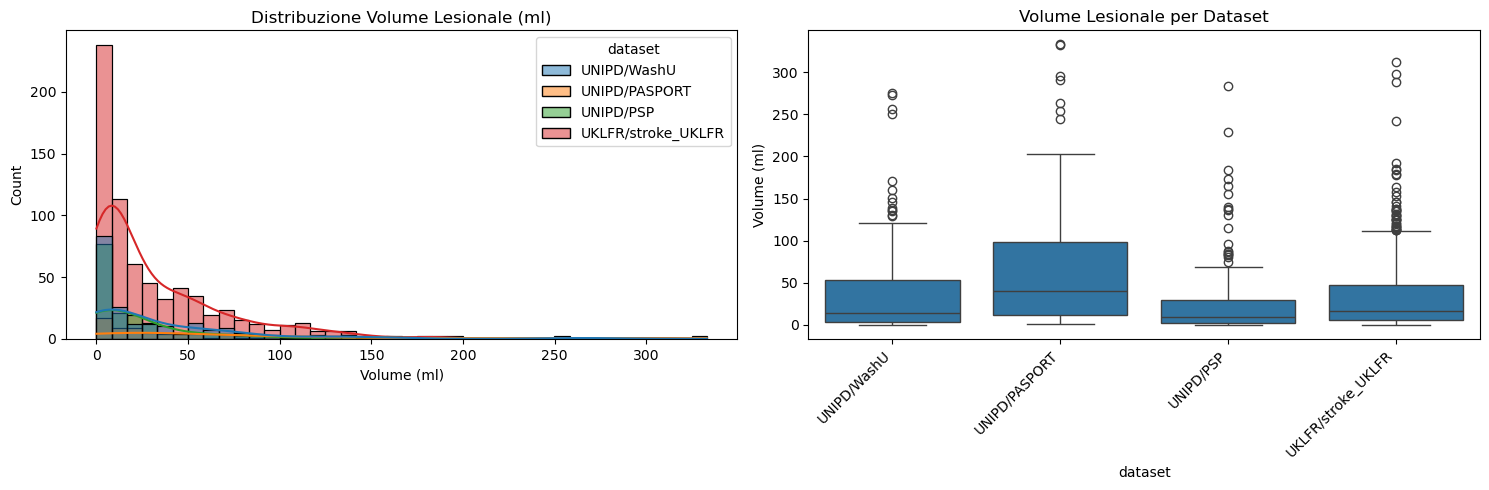

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Istogramma delle distribuzioni
sns.histplot(data=metadata, x='lesion_volume_ml', hue='dataset', kde=True, bins=40, ax=axes[0])
axes[0].set_title('Distribuzione Volume Lesionale (ml)')
axes[0].set_xlabel('Volume (ml)')

# Plot 2: Boxplot per individuare mediane e outlier
sns.boxplot(data=metadata, x='dataset', y='lesion_volume_ml', ax=axes[1])
axes[1].set_title('Volume Lesionale per Dataset')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('Volume (ml)')

plt.tight_layout()
plt.show()


### Distribuzione Violin ed ECDF
- **Violin Plot**: Rivela la densità e la forma esatta della distribuzione volumetrica per ogni dataset.
- **ECDF**: Mostra la probabilità cumulativa, estremamente utile per determinare le soglie (es. il volume sotto il quale ricade il 90% della coorte).

/var/folders/8b/7njxgsdn39gd2dfjjnynjq140000gn/T/ipykernel_86861/567368189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=metadata, x='dataset', y='lesion_volume_ml', inner="quartile", ax=axes[0], palette="muted")
/var/folders/8b/7njxgsdn39gd2dfjjnynjq140000gn/T/ipykernel_86861/567368189.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


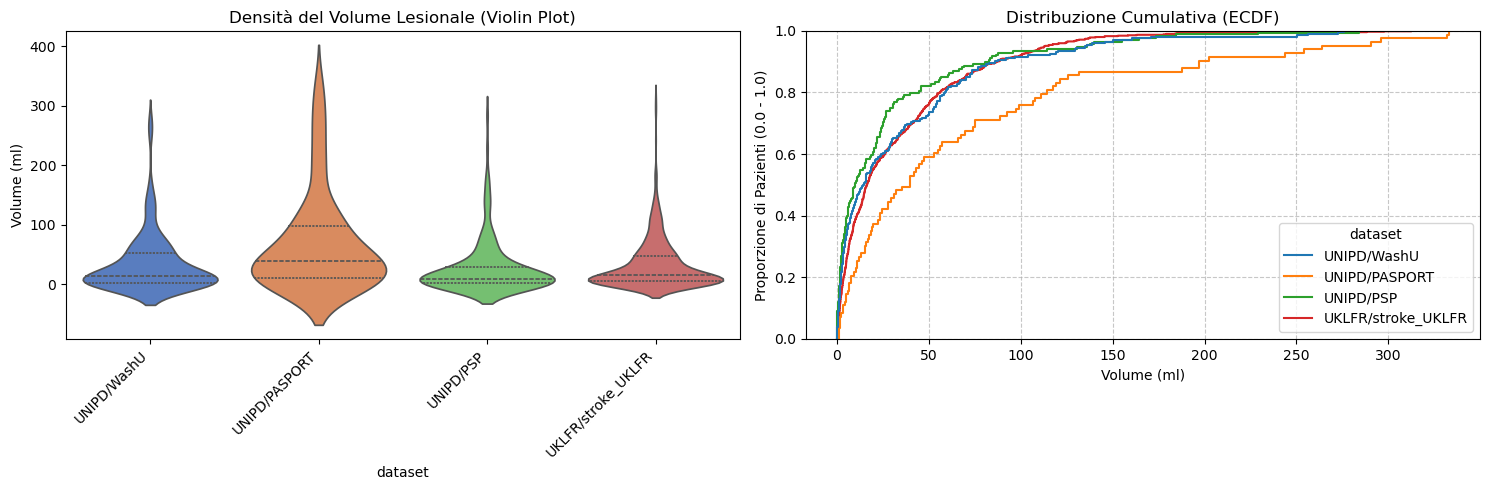

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Violin Plot
sns.violinplot(data=metadata, x='dataset', y='lesion_volume_ml', inner="quartile", ax=axes[0], palette="muted")
axes[0].set_title('Densità del Volume Lesionale (Violin Plot)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('Volume (ml)')

# Plot 2: ECDF Plot
sns.ecdfplot(data=metadata, x='lesion_volume_ml', hue='dataset', ax=axes[1])
axes[1].set_title('Distribuzione Cumulativa (ECDF)')
axes[1].set_xlabel('Volume (ml)')
axes[1].set_ylabel('Proporzione di Pazienti (0.0 - 1.0)')

# Aggiungiamo una griglia leggera per rendere più facile la lettura delle soglie
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Analisi dei Percentili Volumetrici
Calcolo dei percentili chiave (dal 5° al 99°) per quantificare in modo esatto le soglie di volume lesionale, sia sull'intera coorte che stratificate per singolo dataset. Questo ci permette di avere dei numeri concreti per definire cosa costituisce una lesione "estrema" e confrontare matematicamente le distribuzioni.


In [14]:
percentili_chiave = [0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

print("--- Percentili Globali (Intera Coorte) ---")
display(metadata['lesion_volume_ml'].quantile(percentili_chiave).to_frame().T)

print("\n--- Percentili per Singolo Dataset ---")
# .unstack() trasforma il risultato in una bella tabella leggibile
tabella_percentili = metadata.groupby('dataset')['lesion_volume_ml'].quantile(percentili_chiave).unstack()
display(tabella_percentili)

--- Percentili Globali (Intera Coorte) ---


,0.05,0.25,0.50,0.75,0.90,0.95,0.99
lesion_volume_ml,0.7636,4.474,16.08,49.406,92.6,129.326,255.22232



--- Percentili per Singolo Dataset ---


,0.05,0.25,0.50,0.75,0.90,0.95,0.99
dataset,,,,,,,
UKLFR/stroke_UKLFR,1.0560,5.176,16.328,47.752,86.8784,112.9104,179.21920
UNIPD/PASPORT,1.7384,11.536,39.744,98.124,196.8224,262.8992,332.05280
UNIPD/PSP,0.2720,2.326,9.848,29.316,81.0600,134.1452,199.07416
UNIPD/WashU,0.6164,3.188,14.524,52.936,85.6416,134.8956,256.06376


**Come leggere la tabella dei percentili:**
- Le colonne (`0.50`, `0.90`...) indicano la *percentuale di pazienti* che ha un volume inferiore al valore riportato.
- **0.50 (Mediana):** Lo spartiacque. Esattamente metà dei pazienti ha una lesione più piccola di questo volume in ml.
- **0.75 / 0.90 (Soglie di gravità):** I valori sotto cui ricade il 75% o il 90% della coorte. Chi supera queste soglie rientra rispettivamente nel 25% o 10% dei casi "estremi". 

*Nota clinica:* Confrontando le colonne a parità di percentile (es. `0.75`), la differenza quantifica visivamente quanto le lesioni in PASPORT siano sistematicamente più estese rispetto agli altri dataset per essere classificate come "gravi".

### Focus sulla "Coda Lunga" (Lesioni Estreme)
Isoliamo esclusivamente i pazienti oltre il 75° percentile per analizzare la "coda destra" della distribuzione. Questo ci permette di verificare numericamente la sproporzione vista nei grafici e capire esattamente quale dataset contribuisce maggiormente ai casi clinici più severi (lesioni massive).


Soglia del 75° percentile (Top 25% della coorte): 49.41 ml

Quanti pazienti 'gravi' (oltre la soglia) ha ogni dataset?


dataset
UKLFR/stroke_UKLFR    168
UNIPD/WashU            56
UNIPD/PASPORT          34
UNIPD/PSP              30
Name: count, dtype: int64


Che percentuale rappresenta sui pazienti totali di quel dataset?
- UNIPD/WashU         : 56/202 (27.7%)
- UNIPD/PASPORT       : 34/83 (41.0%)
- UNIPD/PSP           : 30/168 (17.9%)
- UKLFR/stroke_UKLFR  : 168/697 (24.1%)


/var/folders/8b/7njxgsdn39gd2dfjjnynjq140000gn/T/ipykernel_86861/406717928.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


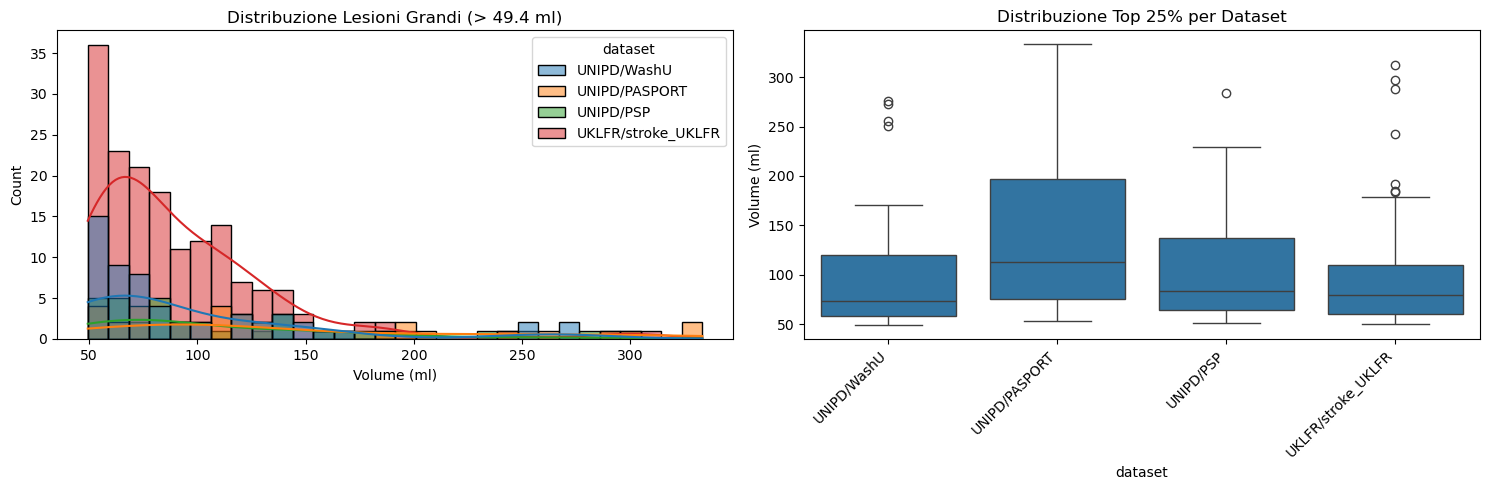

In [15]:
# Calcoliamo il 75° percentile (isolerà il 25% di lesioni più grandi)
threshold_75 = metadata['lesion_volume_ml'].quantile(0.75)
print(f"Soglia del 75° percentile (Top 25% della coorte): {threshold_75:.2f} ml\n")

# Filtriamo il dataframe
large_lesions_df = metadata[metadata['lesion_volume_ml'] > threshold_75]

print("Quanti pazienti 'gravi' (oltre la soglia) ha ogni dataset?")
display(large_lesions_df['dataset'].value_counts())

print("\nChe percentuale rappresenta sui pazienti totali di quel dataset?")
for dataset in DATASETS:
    tot_dataset = (metadata['dataset'] == dataset).sum()
    big_dataset = (large_lesions_df['dataset'] == dataset).sum()
    print(f"- {dataset:20s}: {big_dataset}/{tot_dataset} ({(big_dataset/tot_dataset)*100:.1f}%)")

# Creiamo un plot dedicato solo a questa coda
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Istogramma solo per lesioni > soglia
sns.histplot(data=large_lesions_df, x='lesion_volume_ml', hue='dataset', kde=True, bins=30, ax=axes[0])
axes[0].set_title(f'Distribuzione Lesioni Grandi (> {threshold_75:.1f} ml)')
axes[0].set_xlabel('Volume (ml)')

# Plot 2: Boxplot
sns.boxplot(data=large_lesions_df, x='dataset', y='lesion_volume_ml', ax=axes[1])
axes[1].set_title('Distribuzione Top 25% per Dataset')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('Volume (ml)')

plt.tight_layout()
plt.show()


## Riduzione  (Artefatto 2D)

Ora che abbiamo concluso l'EDA sfruttando la geometria 3D intatta, scartiamo i voxel che non sono mai stati lesionati in nessun paziente. È un'ottimizzazione essenziale per risparmiare memoria e calcolo: una colonna interamente a 0 non contribuisce ad alcuna distanza matematica nei successivi algoritmi di clustering. Infine, salviamo l'artefatto per i prossimi step.

In [ ]:
# === CODICE DI GENERAZIONE E SALVATAGGIO (COMMENTATO) ===
# Mantiene solo i voxel lesionati in almeno un soggetto
# non_constant = X.any(axis=0)
# X_reduced = X[:, non_constant]
#
# print(f"Voxel totali originali: {X.shape[1]}")
# print(f"Voxel non-costanti (utili): {X_reduced.shape[1]}")
# print(f"Dimensione matrice salvata: {X_reduced.shape}")
#
# Salvataggio su disco
# np.save(CACHE_DIR / "X_reduced.npy", X_reduced)
# np.save(CACHE_DIR / "non_constant.npy", non_constant)
# metadata.to_csv(CACHE_DIR / "metadata.csv", index=False)
# =========================================================


## Frequenza Voxel-wise

Frequenza voxel-wise calcolata su 254865 feature (voxel utili)
Voxel mai lesionati in nessun soggetto: 0 (atteso 0)
Voxel lesionati in tutti i soggetti: 0 (atteso 0)
Voxel lesionati in almeno il 10% della coorte (core dell'overlap): 3642
Voxel più frequentemente lesionato in assoluto: 180/1150 soggetti (15.7%)


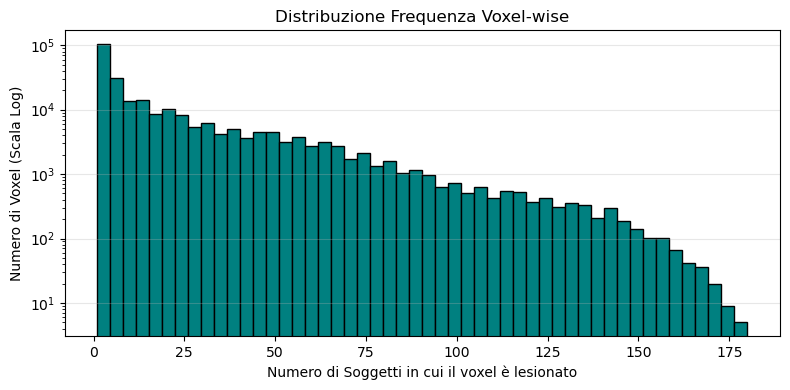

In [24]:
import matplotlib.pyplot as plt

# Calcola la somma lungo le colonne (quanti soggetti hanno un 1 in quel voxel specifico)
voxel_freqs = X_reduced.sum(axis=0)
n_subjects = X_reduced.shape[0]

print(f"Frequenza voxel-wise calcolata su {X_reduced.shape[1]} feature (voxel utili)")
print(f"Voxel mai lesionati in nessun soggetto: {(voxel_freqs == 0).sum()} (atteso 0)")
print(f"Voxel lesionati in tutti i soggetti: {(voxel_freqs == n_subjects).sum()} (atteso 0)")
print(f"Voxel lesionati in almeno il 10% della coorte (core dell'overlap): {(voxel_freqs >= 0.10 * n_subjects).sum()}")
print(f"Voxel più frequentemente lesionato in assoluto: {voxel_freqs.max()}/{n_subjects} soggetti ({(voxel_freqs.max()/n_subjects)*100:.1f}%)")

# Creazione del Plot
plt.figure(figsize=(8, 4))
plt.hist(voxel_freqs, bins=50, color='teal', edgecolor='black')
plt.title("Distribuzione Frequenza Voxel-wise")
plt.xlabel("Numero di Soggetti in cui il voxel è lesionato")
plt.ylabel("Numero di Voxel (Scala Log)")
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Analizziamo la distribuzione di quante volte ogni singolo voxel (feature) risulta lesionato all'interno dell'intera coorte. Questo controllo ci permette di quantificare l'overlap lesionale globale e confermare matematicamente che l'artefatto sia stato ripulito dai voxel inutili.
